# Simulating tibial SSEP data
This notebook defines a simple simulator for tibial SSEP data, which can be used to generate synthetic datasets for testing and benchmarking analysis pipelines. The simulator is designed to be flexible, allowing for different peak shapes, jitter, and noise levels. The core idea is to define a base `Peak` class that models a single SSEP component, and then create child classes that implement specific peak shapes (e.g., Gaussian with rebound, difference-of-exponentials). The main simulation function then combines these peaks with optional jitter and noise to produce realistic synthetic SSEP signals.




In the next cell, we define the base `Peak` class and two child classes: `GaussianReboundPeak` and `DiffExpPeak`. Each class has a `waveform` method that generates the time course of the peak given an array of time points. The main simulation function, `simulate_tibial_ssep_single_trial`, takes a list of peaks and simulates a single trial by summing their waveforms, adding jitter to the latency and amplitude, and optionally adding pink noise.

In [84]:
import numpy as np
from dataclasses import dataclass, field

# ----------------------------
# Base class
# ----------------------------
@dataclass
class Peak:
    name: str
    latency_ms: float
    amp_uv: float
    width_ms: float = 5.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        return self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)


# ----------------------------
# Child 1: Gaussian + rebound
# ----------------------------
@dataclass
class GaussianReboundPeak(Peak):
    width_ms: float = 4.0
    rebound_frac: float = 0.25
    rebound_delay_ms: float = 8.0
    rebound_width_ms: float = 6.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        main = self.amp_uv * np.exp(-0.5 * ((t_ms - self.latency_ms) / self.width_ms) ** 2)
        rebound = (-self.amp_uv * self.rebound_frac) * np.exp(
            -0.5 * ((t_ms - (self.latency_ms + self.rebound_delay_ms)) / self.rebound_width_ms) ** 2
        )
        return main + rebound


# ----------------------------
# Child 2: Difference-of-exponentials (peak time = latency_ms)
# ----------------------------
@dataclass
class DiffExpPeak(Peak):
    tau_rise_ms: float = 1.0
    tau_decay_ms: float = 8.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        tr, td = self.tau_rise_ms, self.tau_decay_ms
        if td <= tr:
            raise ValueError(f"{self.name}: tau_decay_ms must be > tau_rise_ms")

        dt = t_ms - self.latency_ms
        y = np.zeros_like(t_ms, dtype=float)

        m = dt >= 0
        d = dt[m]

        raw = np.exp(-d / td) - np.exp(-d / tr)

        d_star = (tr * td / (td - tr)) * np.log(td / tr)
        raw_max = np.exp(-d_star / td) - np.exp(-d_star / tr)

        y[m] = self.amp_uv * (raw / raw_max)
        return y

# ----------------------------
# Child 3: wavelet-shaped peak (Morlet wavelet with specified frequency, length where the center of the wavelet is at latency_ms
@dataclass
class WaveletPeak(Peak):
    freq_hz: float = 40.0
    n_cycles: float = 7.0

    def waveform(self, t_ms: np.ndarray) -> np.ndarray:
        from scipy.signal import morlet2

        sf = self.freq_hz / self.n_cycles
        w = morlet2(M=len(t_ms), w=self.n_cycles, s=sf * (1000.0 / self.fs))
        # shift wavelet so its center is at latency_ms
        t_shifted = t_ms - self.latency_ms
        idx = np.argmin(np.abs(t_shifted))
        w_shifted = np.roll(w, idx - len(w) // 2)
        return self.amp_uv * w_shifted.real



# ----------------------------
# Simulator: now peak-agnostic
# ----------------------------
def simulate_tibial_ssep_single_trial(
        fs=5000,
        tmin_ms=-20.0,
        tmax_ms=120.0,
        peaks=None,
        latency_jitter_ms=0.6,
        amp_jitter_frac=0.10,
        noise_rms_uv=0.0,
        rng_seed=None,
        add_ringing=False,
):
    rng = np.random.default_rng(rng_seed)
    t_ms = np.arange(tmin_ms, tmax_ms, 1000.0 / fs)
    sig = np.zeros_like(t_ms, dtype=float)

    for p in peaks:
        # trial jitter: make a shallow copy with jittered params
        lat = p.latency_ms + rng.normal(0, latency_jitter_ms)
        amp = p.amp_uv * (1.0 + rng.normal(0, amp_jitter_frac))

        # copy object while preserving its class + extra fields
        p_trial = type(p)(**{**p.__dict__, "latency_ms": lat, "amp_uv": amp})
        sig += p_trial.waveform(t_ms)

    if noise_rms_uv > 0:
        sig += rng.normal(0, noise_rms_uv, size=len(t_ms))

    return t_ms, sig

In the following cell we will define some filtering functions that can be used to process the simulated data. These include a simple low-pass filter and a band-pass filter, which can be applied to the simulated SSEP signals to mimic typical preprocessing steps in real data analysis pipelines. The filters are implemented using Butterworth designs, and we will use the `scipy.signal` library for the actual filtering operations. Importantly, these filters are zero-phase (using `filtfilt`) to avoid introducing any phase distortion, which is crucial for preserving the temporal characteristics of the SSEP peaks.

In [2]:
# defining some simple filters for processing the simulated data
from scipy.signal import butter, filtfilt

def lowpass_filter(data, fs, cutoff_hz=200.0, order=4):
    b, a = butter(order, cutoff_hz / (0.5 * fs), btype="low")
    return filtfilt(b, a, data)

def bandpass_filter(data, fs, low_hz=1.0, high_hz=200.0, order=4):
    b, a = butter(order, [low_hz / (0.5 * fs), high_hz / (0.5 * fs)], btype="band")
    return filtfilt(b, a, data)



In the next cell we will define a class called preprocessor that can be used to apply a sequence of preprocessing steps to the simulated SSEP data. This class will allow us to easily apply multiple filters and other transformations in a consistent way. The `Preprocessor` class will have methods for adding filters to the processing pipeline, as well as a method for applying the entire pipeline to a given signal. This design allows for flexibility in how we preprocess the simulated data, and makes it easy to experiment with different combinations of filters and parameters.

In [4]:
from dataclasses import dataclass, asdict
from typing import Any

@dataclass
class ProcessingStep:
    name: str
    params: dict[str, Any]

class Preprocessor:
    def __init__(self, fs: int):
        self.fs = fs
        self.steps: list[ProcessingStep] = []

    def add_lowpass(self, cutoff_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("lowpass", {"cutoff_hz": cutoff_hz, "order": order})
        )

    def add_bandpass(self, low_hz: float = 1.0, high_hz: float = 200.0, order: int = 4):
        self.steps.append(
            ProcessingStep("bandpass", {"low_hz": low_hz, "high_hz": high_hz, "order": order})
        )

    def apply(self, data):
        for step in self.steps:
            data = self._apply_step(step, data)
        return data

    def _apply_step(self, step: ProcessingStep, data):
        if step.name == "lowpass":
            return lowpass_filter(data, self.fs, **step.params)
        if step.name == "bandpass":
            return bandpass_filter(data, self.fs, **step.params)
        raise ValueError(f"Unknown step: {step.name}")

    def describe(self):
        # JSON-friendly list of dicts
        return [asdict(s) for s in self.steps]

    @classmethod
    def from_description(cls, fs: int, steps_desc: list[dict[str, Any]]):
        """
        Rebuild a Preprocessor from something previously returned by describe().
        """
        p = cls(fs)
        for d in steps_desc:
            p.steps.append(ProcessingStep(name=d["name"], params=d["params"]))
        return p


#small sanity check to make sure the preprocessor can be created and applied without errors
prep = Preprocessor(fs=5000)
prep.add_bandpass(10, 200)
prep.add_lowpass(150, order=2)

print(prep.describe())
desc = prep.describe()
# save desc somewhere (JSON, file, inside Dataset, etc.)

prep2 = Preprocessor.from_description(fs=5000, steps_desc=desc)
print(prep2.describe())


[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]
[{'name': 'bandpass', 'params': {'low_hz': 10, 'high_hz': 200, 'order': 4}}, {'name': 'lowpass', 'params': {'cutoff_hz': 150, 'order': 2}}]


#In the next cell we will define a class called preprocessor that can be used to apply a sequence of preprocessing steps to the simulated SSEP data. This class will allow us to easily apply multiple filters and other transformations in a consistent way. The `Preprocessor` class will have methods for adding filters to the processing pipeline, as well as a method for applying the entire pipeline to a given signal. This design allows for flexibility in how we preprocess the simulated data, and makes it easy to experiment with different combinations of filters and parameters.In this cell we define a class called dataset that can be used to generate and store multiple simulated trials of tibial SSEP data. The `Dataset` class takes a list of peaks and simulation parameters, and has a method called `generate_trials` that creates a specified number of trials by calling the `simulate_tibial_ssep_single_trial` function for each trial. The generated data is stored in a list of tuples, where each tuple contains the time points and the corresponding signal for that trial. This class provides a convenient way to manage and access the simulated dataset for further analysis or testing of processing pipelines.

Generated 300 trials with 2100 time points each.
First trial time range: -160.0 ms to 259.79999999997614 ms
First trial signal snippet: [-3.90207038 -2.60435901  0.25568081 -0.63248518 -0.03360232 -1.70608786
  1.75879595  1.55558387  0.1320614   2.25448241] ...


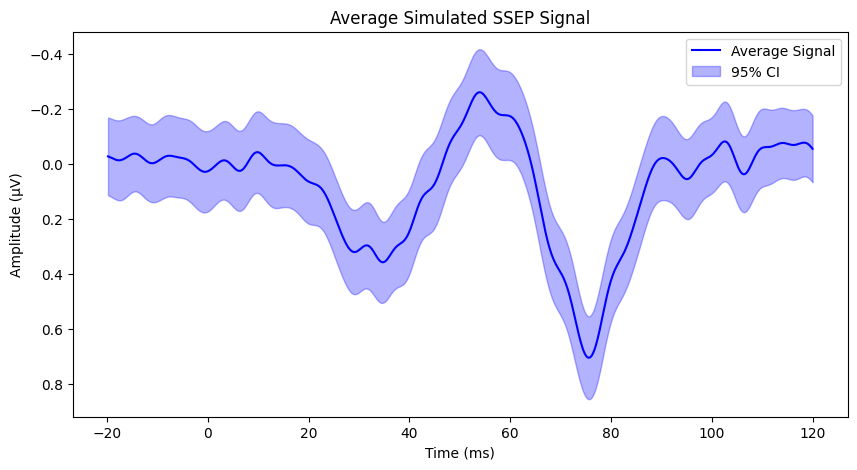

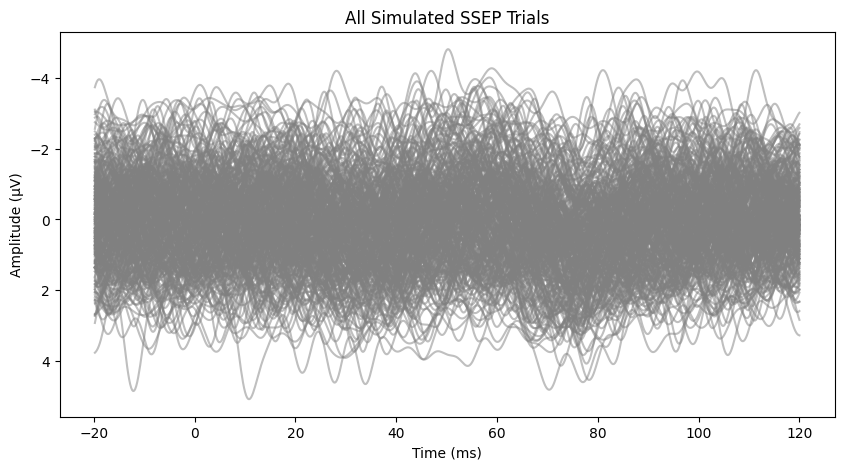

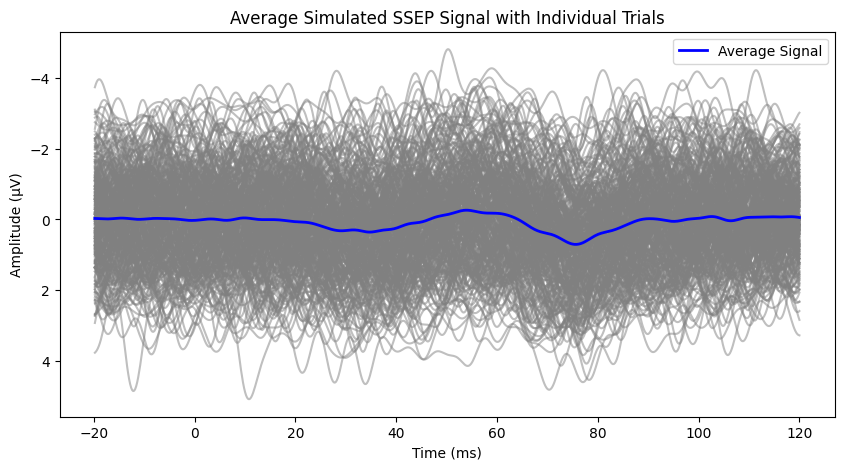

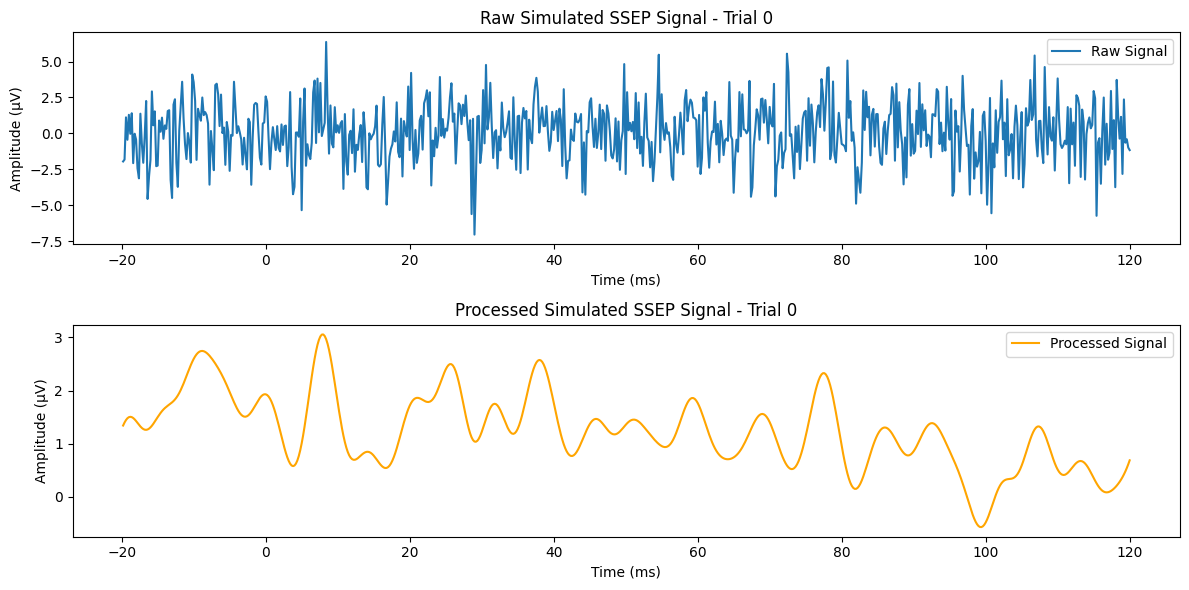

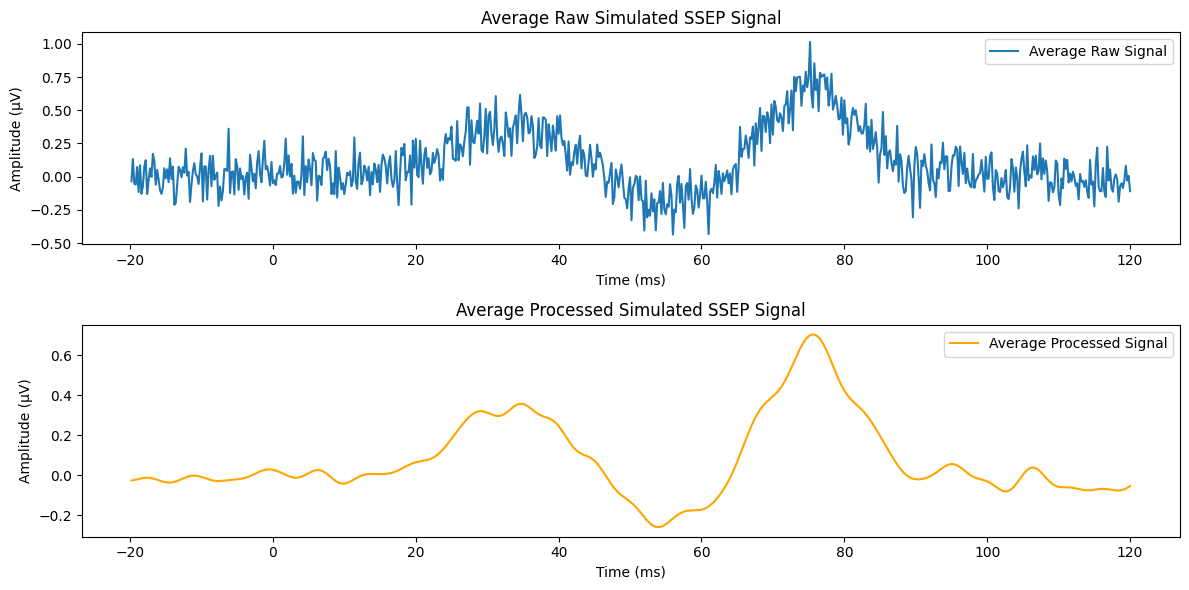

In [6]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class Dataset:
    peaks: list
    fs: int = 5000
    tmin_ms: float = -20.0
    tmax_ms: float = 120.0
    pad_frac: float = 1  # extra window (as a fraction of original duration) to reduce filter edge artifacts
    crop_after_preprocess: bool = True  # crop back to [tmin_ms, tmax_ms] after preprocessing

    latency_jitter_ms: float = 0.6
    amp_jitter_frac: float = 0.10
    noise_rms_uv: float = 0.0
    rng_seed: int | None = None

    trials: list = field(default_factory=list)
    trials_raw: list | None = None  # optional backup of original trials
    processing_log: list = field(default_factory=list)

    def generate_trials(self, n_trials=100):
        self.trials = []
        for i in range(n_trials):
            # Simulate a wider time window so zero-phase filtering (filtfilt) has room to settle.
            dur_ms = self.tmax_ms - self.tmin_ms
            pad_each_ms = 0.5 * self.pad_frac * dur_ms  # half on each side
            tmin_ext = self.tmin_ms - pad_each_ms
            tmax_ext = self.tmax_ms + pad_each_ms
            t_ms, sig = simulate_tibial_ssep_single_trial(
                fs=self.fs,
                tmin_ms=tmin_ext,
                tmax_ms=tmax_ext,
                peaks=self.peaks,
                latency_jitter_ms=self.latency_jitter_ms,
                amp_jitter_frac=self.amp_jitter_frac,
                noise_rms_uv=self.noise_rms_uv,
                rng_seed=(self.rng_seed + i) if self.rng_seed is not None else None,
            )
            self.trials.append((t_ms, sig))

        # reset processing history when regenerating
        self.trials_raw = None
        self.processing_log.clear()

    def _crop_trials_to_window(self, tmin_ms: float, tmax_ms: float):
        """Crop all trials to a target [tmin_ms, tmax_ms] window."""
        def _crop_one(trial):
            t_ms, sig = trial
            m = (t_ms >= tmin_ms) & (t_ms < tmax_ms)
            return t_ms[m], sig[m]

        self.trials = [_crop_one(tr) for tr in self.trials]
        if self.trials_raw is not None:
            self.trials_raw = [_crop_one(tr) for tr in self.trials_raw]


    def average(self):
        if not self.trials:
            raise ValueError("No trials generated yet. Call generate_trials() first.")
        sigs = np.array([sig for _, sig in self.trials])
        avg_sig = np.mean(sigs, axis=0)
        return self.trials[0][0], avg_sig

    def preprocess(self, preprocessor: "Preprocessor", keep_raw: bool = True):
        if not self.trials:
            raise ValueError("No trials to preprocess. Call generate_trials() first.")

        if keep_raw and self.trials_raw is None:
            # store original trials only once (first preprocessing call)
            self.trials_raw = list(self.trials)

        self.trials = [(t_ms, preprocessor.apply(sig)) for t_ms, sig in self.trials]

        if self.crop_after_preprocess and self.pad_frac > 0:
            # Crop back to the original analysis window after filtering.
            self._crop_trials_to_window(self.tmin_ms, self.tmax_ms)

        self.processing_log.append(
            {"fs": preprocessor.fs, "steps": preprocessor.describe()}
        )

    # define a method to plot the average signal across trials, with optional confidence intervals
    def plot_average(self, show_ci=False):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue")
        if show_ci:
            sigs = np.array([sig for _, sig in self.trials])
            ci = 1.96 * np.std(sigs, axis=0) / np.sqrt(len(sigs))
            plt.fill_between(t_ms, avg_sig - ci, avg_sig + ci, color="blue", alpha=0.3, label="95% CI")
        plt.title("Average Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        #invert y axis to match typical SSEP plots
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot all individual trials as a spaghetti plot
    def plot_trials(self):
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.title("All Simulated SSEP Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.show()

    # define a method to plot the average signal along with all individual trials
    def plot_average_with_trials(self):
        t_ms, avg_sig = self.average()
        plt.figure(figsize=(10, 5))
        for t_ms, sig in self.trials:
            plt.plot(t_ms, sig, color="gray", alpha=0.5)
        plt.plot(t_ms, avg_sig, label="Average Signal", color="blue", linewidth=2)
        plt.title("Average Simulated SSEP Signal with Individual Trials")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()

    # define a method to plot the raw and processed signals for a given trial index
    def plot_trial_comparison(self, trial_index=0):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, raw_sig = self.trials_raw[trial_index]
        _, processed_sig = self.trials[trial_index]
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, raw_sig, label="Raw Signal")
        plt.title(f"Raw Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
        plt.title(f"Processed Simulated SSEP Signal - Trial {trial_index}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # define a method to plot the average signal before and after preprocessing to visually confirm the effects of the processing steps
    def plot_average_comparison(self):
        if self.trials_raw is None:
            raise ValueError("No raw trials stored. Call preprocess() with keep_raw=True first.")
        t_ms, avg_raw = self.average_from_trials(self.trials_raw)
        _, avg_processed = self.average()
        plt.figure(figsize=(12, 6))
        plt.subplot(2, 1, 1)
        plt.plot(t_ms, avg_raw, label="Average Raw Signal")
        plt.title("Average Raw Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(t_ms, avg_processed, label="Average Processed Signal", color="orange")
        plt.title("Average Processed Simulated SSEP Signal")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # helper method to compute average from a given list of trials (used for raw vs processed comparison)
    def average_from_trials(self, trials):
        sigs = np.array([sig for _, sig in trials])
        avg_sig = np.mean(sigs, axis=0)
        return trials[0][0], avg_sig



# sanity check for Dataset class
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+.5, width_ms=10.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+.7, width_ms=6.0)
]
dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=2, rng_seed=42,pad_frac=2)
dataset.generate_trials(n_trials=300)

#print some info about the generated dataset
print(f"Generated {len(dataset.trials)} trials with {len(dataset.trials[0][0])} time points each.")
print(f"First trial time range: {dataset.trials[0][0][0]} ms to {dataset.trials[0][0][-1]} ms")
print(f"First trial signal snippet: {dataset.trials[0][1][:10]} ...")

# apply a simple preprocessing step to the dataset and check that it works without errors
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
dataset.preprocess(preprocessor)

# testing plotting methods for the dataset
dataset.plot_average(show_ci=True)
dataset.plot_trials()
dataset.plot_average_with_trials()
dataset.plot_trial_comparison(trial_index=0)
dataset.plot_average_comparison()



In this cell we will demonstrate how to use the `Dataset` and `Preprocessor` classes to generate a simulated dataset of tibial SSEP trials and apply a sequence of preprocessing steps to the data. We will create a dataset with a specified number of trials, and then use the `Preprocessor` class to apply both a low-pass filter and a band-pass filter to each trial's signal. Finally, we will visualize the raw and processed signals for a few example trials to illustrate the effects of the preprocessing steps. This will help us understand how the simulated data can be used to test and validate analysis pipelines, and how the preprocessing steps can affect the characteristics of the SSEP signals.

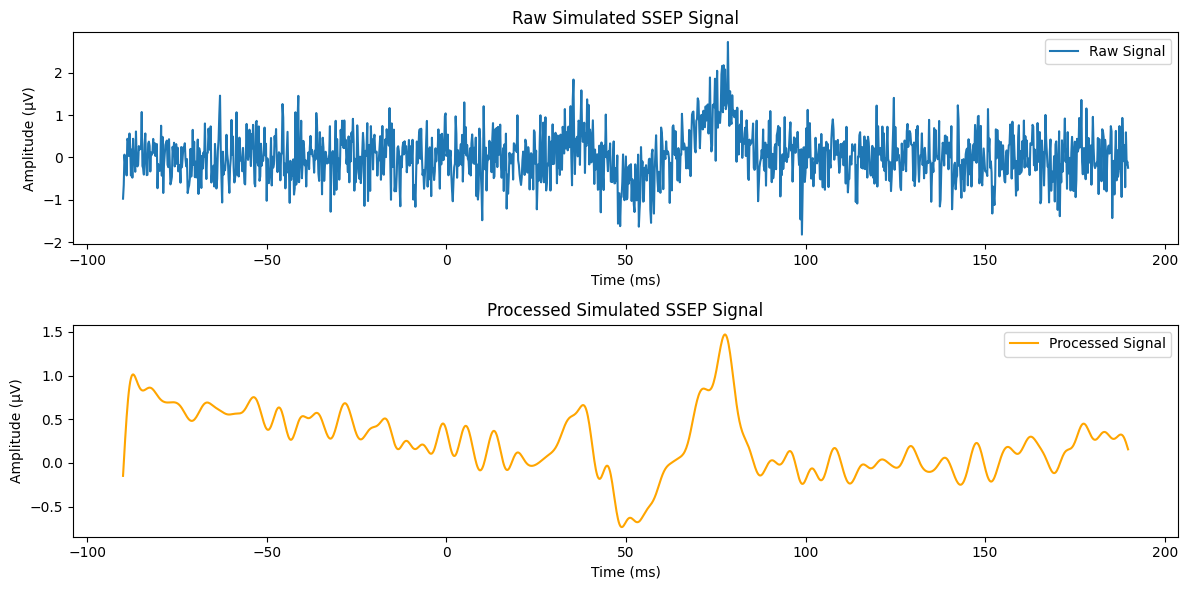

In [7]:
# Example usage
# Define some peaks for the simulation
custom_peaks = [
    GaussianReboundPeak("P37", latency_ms=37.0, amp_uv=+1.0, width_ms=5.0,
                        rebound_frac=.6, rebound_delay_ms=12, rebound_width_ms=12),
    Peak("P75", latency_ms=75.0, amp_uv=+1.2, width_ms=6.0)
]
# Create a dataset with the defined peaks
dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=0.5, rng_seed=42)
dataset.generate_trials(n_trials=10)
# Create a preprocessor and add some filters
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_lowpass(cutoff_hz=200.0, order=4)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
# Apply preprocessing to the first trial and visualize
import matplotlib.pyplot as plt
t_ms, raw_sig = dataset.trials[0]
processed_sig = preprocessor.apply(raw_sig)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_ms, raw_sig, label="Raw Signal")
plt.title("Raw Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_ms, processed_sig, label="Processed Signal", color="orange")
plt.title("Processed Simulated SSEP Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.tight_layout()
plt.show()


This cell we will generate n subjects worth of simulated tibial SSEP data, each with a specified number of trials. We will then apply the same preprocessing pipeline to each subject's dataset and visualize the average signal across subjects to confirm that the simulated peaks are present and that the preprocessing steps are working as expected. This will allow us to create a larger synthetic dataset that can be used for testing and validating analysis pipelines, and to ensure that the simulated data behaves in a realistic manner across multiple subjects.

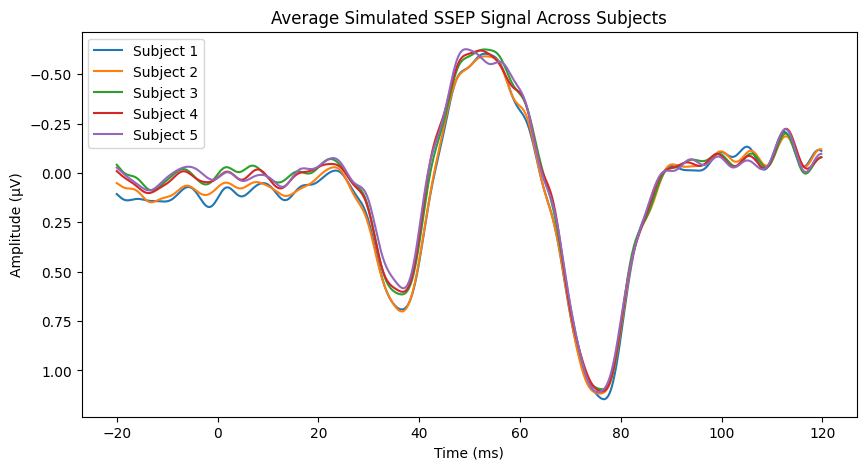

In [8]:
n=5  # number of subjects
subjects = []
for i in range(n):
    dataset = Dataset(peaks=custom_peaks, fs=5000, noise_rms_uv=0.5, rng_seed=42+i)
    dataset.generate_trials(n_trials=10)
    dataset.preprocess(preprocessor)
    subjects.append(dataset)
# Plot average signal across subjects
plt.figure(figsize=(10, 5))
for i, dataset in enumerate(subjects):
    t_ms, avg_sig = dataset.average()
    plt.plot(t_ms, avg_sig, label=f"Subject {i+1}")
plt.title("Average Simulated SSEP Signal Across Subjects")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

## Time-frequency decomposition (complex Morlet wavelets)

This section computes:
- **ITPC** (inter-trial phase coherence)
- **Total power** (mean single-trial power)
- **Evoked / phase-locked power** (power of the ERP)
- **Induced / non-phase-locked power** (total − evoked)

The implementation uses **FFT-based complex Morlet wavelet convolution** with explicit control over:
- frequency grid
- number of cycles (fixed or frequency-dependent)
- wavelet length (in σ units)
- padding strategy (reflect/constant) + cropping
- optional baseline normalization


In [100]:

import numpy as np
import matplotlib.pyplot as plt


def morlet_wavelet(
        f_hz: float,
        fs: float,
        n_cycles: float,
        sigma_mult: float = 3.0,
        normalize: str = "unit_energy",
):
    """
    Complex Morlet wavelet centered at 0.

    Controls:
      - n_cycles: time/frequency tradeoff (higher => better frequency resolution)
      - sigma_mult: wavelet time support in units of sigma (3-4 is common)
      - normalize:
          * "unit_energy" (recommended for power comparability across freqs)
          * "peak_fft" (quick-and-common; power scaling differs)
          * None
    """
    sigma = n_cycles / (2 * np.pi * f_hz)  # seconds
    half = int(np.ceil(sigma_mult * sigma * fs))  # samples
    t = np.arange(-half, half + 1) / fs

    w = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t**2) / (2 * sigma**2))

    if normalize == "unit_energy":
        w = w / np.sqrt(np.sum(np.abs(w) ** 2))
    elif normalize == "peak_fft":
        # normalize after FFT in the transform function
        pass
    elif normalize is None:
        pass
    else:
        raise ValueError("normalize must be 'unit_energy', 'peak_fft', or None")

    return t, w



def wavelet_transform_fft(
        data: np.ndarray,
        fs: float,
        freqs_hz: np.ndarray,
        n_cycles,
        sigma_mult: float = 3.0,
        pad_mode: str = "reflect",
        normalize: str = "unit_energy",
):
    if data.ndim != 2:
        raise ValueError("data must be 2D: (n_trials, n_times)")

    n_trials, n_times = data.shape
    freqs_hz = np.asarray(freqs_hz, dtype=float)

    # handle n_cycles scalar vs vector
    if np.isscalar(n_cycles):
        n_cycles = np.ones(freqs_hz.shape[0]) * float(n_cycles)
    else:
        n_cycles = np.asarray(n_cycles, dtype=float)
        if n_cycles.shape[0] != freqs_hz.shape[0]:
            raise ValueError("n_cycles must be scalar or have same length as freqs_hz")

    # pad based on the *largest sigma* (longest wavelet)
    sigmas = n_cycles / (2 * np.pi * freqs_hz)
    sigma_max = np.max(sigmas)
    pad = int(np.ceil(sigma_mult * sigma_max * fs))

    # pad trials
    if pad_mode == "reflect":
        data_pad = np.pad(data, ((0, 0), (pad, pad)), mode="reflect")
    elif pad_mode == "constant":
        data_pad = np.pad(data, ((0, 0), (pad, pad)), mode="constant")
    else:
        raise ValueError("pad_mode must be 'reflect' or 'constant'")

    n_times_pad = data_pad.shape[1]

    tf = np.zeros((n_trials, freqs_hz.shape[0], n_times), dtype=np.complex128)

    for fi, f in enumerate(freqs_hz):
        _, w = morlet_wavelet(
            f, fs, n_cycles[fi], sigma_mult=sigma_mult, normalize=normalize
        )

        # --- KEY POINTS ---
        # 1) linear convolution length
        n_conv = n_times_pad + len(w) - 1

        # 2) FFTs
        data_fft = np.fft.fft(data_pad, n=n_conv, axis=1)

        # 3) shift wavelet so its center is at index 0 for FFT convolution
        w0 = np.fft.ifftshift(w)
        w_fft = np.fft.fft(w0, n=n_conv)

        if normalize == "peak_fft":
            w_fft = w_fft / np.max(np.abs(w_fft))

        conv_full = np.fft.ifft(data_fft * w_fft[None, :], axis=1)

        # 4) "same" crop to padded-data length
        half_w = (len(w) - 1) // 2
        conv_same = conv_full[:, half_w:half_w + n_times_pad]

        # 5) remove padding back to original n_times
        conv = conv_same[:, pad:pad + n_times]

        tf[:, fi, :] = conv

    return tf




def compute_itpc_and_power(
        trials: np.ndarray,
        fs: float,
        freqs_hz: np.ndarray,
        n_cycles,
        sigma_mult: float = 3.0,
        pad_mode: str = "reflect",
        normalize: str = "unit_energy",
):
    """
    Returns dict with ITPC, total/evoked/induced power.

    trials: (n_trials, n_times)
    """
    tf = wavelet_transform_fft(
        trials,
        fs,
        freqs_hz,
        n_cycles,
        sigma_mult=sigma_mult,
        pad_mode=pad_mode,
        normalize=normalize,
    )

    # total power (trial-average of power)
    total_power = np.mean(np.abs(tf) ** 2, axis=0)

    # ITPC
    phase = tf / np.maximum(np.abs(tf), 1e-15)
    itpc = np.abs(np.mean(phase, axis=0))

    # evoked (ERP wavelet)
    erp = np.mean(trials, axis=0, keepdims=True)
    tf_erp = wavelet_transform_fft(
        erp,
        fs,
        freqs_hz,
        n_cycles,
        sigma_mult=sigma_mult,
        pad_mode=pad_mode,
        normalize=normalize,
    )
    evoked_power = np.abs(tf_erp[0]) ** 2

    # induced
    induced_power = total_power - evoked_power

    return {
        "tf": tf,
        "itpc": itpc,
        "total_power": total_power,
        "evoked_power": evoked_power,
        "induced_power": induced_power,
    }


def baseline_db(power: np.ndarray, t_ms: np.ndarray, baseline_ms=(-20.0, 0.0)):
    """
    Baseline-normalize power to dB relative to baseline interval.
    power: (n_freqs, n_times)
    """
    m = (t_ms >= baseline_ms[0]) & (t_ms <= baseline_ms[1])
    if not np.any(m):
        raise ValueError("Baseline mask is empty. Check baseline_ms and t_ms.")

    base = np.mean(power[:, m], axis=1, keepdims=True)
    base = np.maximum(base, 1e-20)

    return 10 * np.log10(np.maximum(power, 1e-20) / base)


def plot_tf_panels(
        t_ms: np.ndarray,
        freqs_hz: np.ndarray,
        metrics: dict,
        title: str = "",
        baseline_ms=None,
        vlim_db=None,
        cmap="viridis",
):
    """
    Plots 2x2 panels: ITPC, Total power, Evoked power, Induced power.
    Power panels can optionally be baseline-normalized to dB.
    """
    itpc = metrics["itpc"]
    total = metrics["total_power"]
    evoked = metrics["evoked_power"]
    induced = metrics["induced_power"]

    if baseline_ms is not None:
        total = baseline_db(total, t_ms, baseline_ms)
        evoked = baseline_db(evoked, t_ms, baseline_ms)
        induced = baseline_db(induced, t_ms, baseline_ms)

    extent = [t_ms[0], t_ms[-1], freqs_hz[0], freqs_hz[-1]]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    # ITPC
    im0 = axes[0, 0].imshow(
        itpc, aspect="auto", origin="lower", extent=extent, cmap=cmap
    )
    axes[0, 0].set_title("ITPC")
    axes[0, 0].set_xlabel("Time (ms)")
    axes[0, 0].set_ylabel("Frequency (Hz)")
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

    def _imshow_power(ax, arr, ttl):
        if vlim_db is not None and baseline_ms is not None:
            im = ax.imshow(
                arr,
                aspect="auto",
                origin="lower",
                extent=extent,
                cmap=cmap,
                vmin=vlim_db[0],
                vmax=vlim_db[1],
            )
        else:
            im = ax.imshow(
                arr, aspect="auto", origin="lower", extent=extent, cmap=cmap
            )
        ax.set_title(ttl)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Frequency (Hz)")
        return im

    im1 = _imshow_power(
        axes[0, 1], total, "Total power" + (" (dB)" if baseline_ms else "")
    )
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

    im2 = _imshow_power(
        axes[1, 0], evoked, "Evoked power" + (" (dB)" if baseline_ms else "")
    )
    fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

    im3 = _imshow_power(
        axes[1, 1], induced, "Induced power" + (" (dB)" if baseline_ms else "")
    )
    fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

    plt.show()


def plot_freq_traces(
        t_ms: np.ndarray,
        freqs_hz: np.ndarray,
        metrics: dict,
        target_hz: float,
        title: str = "",
        baseline_ms=None,
):
    """
    Plot time courses at the closest frequency bin for power + ITPC.
    """
    fi = int(np.argmin(np.abs(freqs_hz - target_hz)))
    f_sel = freqs_hz[fi]

    itpc = metrics["itpc"][fi]

    if baseline_ms is not None:
        total = baseline_db(metrics["total_power"], t_ms, baseline_ms)[fi]
        evoked = baseline_db(metrics["evoked_power"], t_ms, baseline_ms)[fi]
        induced = baseline_db(metrics["induced_power"], t_ms, baseline_ms)[fi]
    else:
        total = metrics["total_power"][fi]
        evoked = metrics["evoked_power"][fi]
        induced = metrics["induced_power"][fi]

    plt.figure(figsize=(12, 4))
    plt.plot(t_ms, itpc, label=f"ITPC @ {f_sel:.2f} Hz")
    plt.ylim(0, 1.05)
    plt.xlabel("Time (ms)")
    plt.ylabel("ITPC")
    plt.title(title + f" | ITPC @ {f_sel:.2f} Hz")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(t_ms, total, label="Total")
    plt.plot(t_ms, evoked, label="Evoked")
    plt.plot(t_ms, induced, label="Induced")
    plt.xlabel("Time (ms)")
    plt.ylabel("Power" + (" (dB)" if baseline_ms else ""))
    plt.title(title + f" | Power @ {f_sel:.2f} Hz")
    plt.legend()
    plt.show()



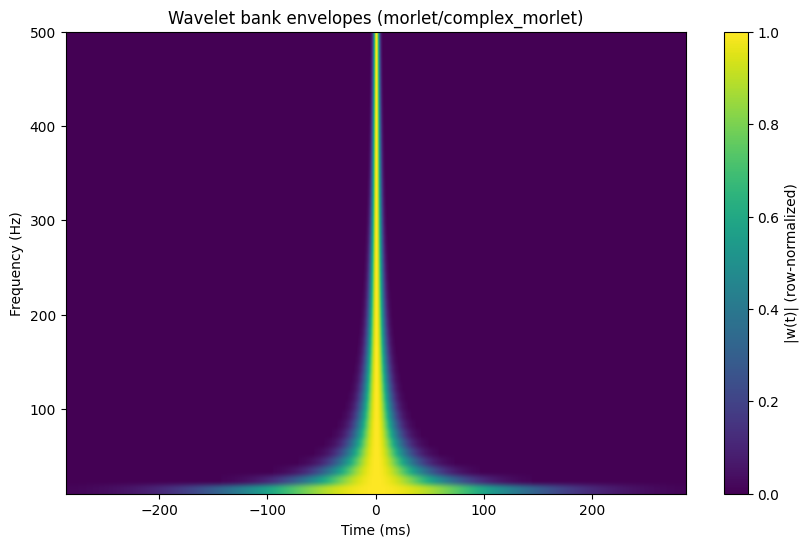

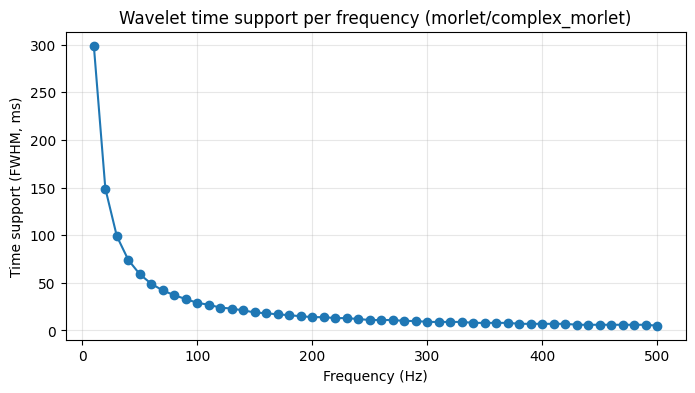

(array([ 10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110.,
        120., 130., 140., 150., 160., 170., 180., 190., 200., 210., 220.,
        230., 240., 250., 260., 270., 280., 290., 300., 310., 320., 330.,
        340., 350., 360., 370., 380., 390., 400., 410., 420., 430., 440.,
        450., 460., 470., 480., 490., 500.]),
 array([299., 149.,  99.,  74.,  59.,  49.,  42.,  37.,  33.,  29.,  27.,
         24.,  23.,  21.,  19.,  18.,  17.,  16.,  15.,  14.,  14.,  13.,
         13.,  12.,  11.,  11.,  11.,  10.,  10.,   9.,   9.,   9.,   9.,
          8.,   8.,   8.,   8.,   7.,   7.,   7.,   7.,   7.,   6.,   6.,
          6.,   6.,   6.,   6.,   6.,   5.]))

In [101]:
from dataclasses import dataclass
from typing import Optional, Union, Dict, Any


@dataclass(frozen=True)
class WaveletFamilySpec:
    """
    Stores the wavelet family and all parameters that define the wavelet bank
    used in the TF decomposition.
    """
    family: str                  # e.g., "morlet"
    variant: str                 # e.g., "complex_morlet"
    fs: float
    freqs_hz: np.ndarray
    n_cycles: np.ndarray
    sigma_mult: float
    normalize: Optional[str]
    pad_mode: str

    def as_dict(self) -> Dict[str, Any]:
        return {
            "family": self.family,
            "variant": self.variant,
            "fs": float(self.fs),
            "freqs_hz": np.asarray(self.freqs_hz, dtype=float),
            "n_cycles": np.asarray(self.n_cycles, dtype=float),
            "sigma_mult": float(self.sigma_mult),
            "normalize": self.normalize,
            "pad_mode": self.pad_mode,
        }


def _coerce_n_cycles(freqs_hz: np.ndarray, n_cycles: Union[float, np.ndarray]) -> np.ndarray:
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    if np.isscalar(n_cycles):
        return np.ones(freqs_hz.shape[0], dtype=float) * float(n_cycles)
    n_cycles = np.asarray(n_cycles, dtype=float)
    if n_cycles.shape[0] != freqs_hz.shape[0]:
        raise ValueError("n_cycles must be scalar or have same length as freqs_hz")
    return n_cycles


def build_morlet_wavelet_family(
        fs: float,
        freqs_hz: np.ndarray,
        n_cycles: Union[float, np.ndarray],
        sigma_mult: float = 3.0,
        normalize: Optional[str] = "unit_energy",
        pad_mode: str = "reflect",
) -> WaveletFamilySpec:
    """
    Convenience constructor for this codebase's wavelet family.
    """
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    n_cycles_vec = _coerce_n_cycles(freqs_hz, n_cycles)

    return WaveletFamilySpec(
        family="morlet",
        variant="complex_morlet",
        fs=fs,
        freqs_hz=freqs_hz,
        n_cycles=n_cycles_vec,
        sigma_mult=sigma_mult,
        normalize=normalize,
        pad_mode=pad_mode,
    )


def plot_morlet_wavelet(
        f_hz: float,
        fs: float,
        n_cycles: float,
        sigma_mult: float = 3.0,
        normalize: Optional[str] = "unit_energy",
        show_fft: bool = True,
        title: str = "",
):
    """
    Plot one Morlet wavelet in time (real/imag + envelope) and optionally its FFT magnitude.
    """
    t, w = morlet_wavelet(f_hz, fs, n_cycles, sigma_mult=sigma_mult, normalize=normalize)

    # Time domain
    plt.figure(figsize=(10, 4))
    plt.plot(t, np.real(w), label="Real")
    plt.plot(t, np.imag(w), label="Imag")
    plt.plot(t, np.abs(w), label="Envelope |w(t)|")
    plt.axvline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    ttl = title if title else f"Complex Morlet (f={f_hz:.2f} Hz, n_cycles={n_cycles}, norm={normalize})"
    plt.title(ttl)
    plt.legend()
    plt.show()

    if not show_fft:
        return

    # Frequency domain (magnitude)
    n = len(w)
    W = np.fft.fftshift(np.fft.fft(w))
    freqs = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, np.abs(W))
    plt.xlim(0, min(fs / 2, f_hz * 5))  # reasonable zoom for Morlet
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("|FFT(w)|")
    plt.title(f"Wavelet spectrum (peak near {f_hz:.2f} Hz)")
    plt.show()


def plot_wavelet_family(
        spec: WaveletFamilySpec,
        freqs_to_plot: Optional[np.ndarray] = None,
        show_fft: bool = False,
):
    """
    Plot a few wavelets from the family spec.
    """
    freqs = spec.freqs_hz if freqs_to_plot is None else np.asarray(freqs_to_plot, dtype=float)

    # map each requested freq to closest bin in spec.freqs_hz so we use consistent n_cycles
    for f in freqs:
        fi = int(np.argmin(np.abs(spec.freqs_hz - f)))
        plot_morlet_wavelet(
            f_hz=float(spec.freqs_hz[fi]),
            fs=spec.fs,
            n_cycles=float(spec.n_cycles[fi]),
            sigma_mult=spec.sigma_mult,
            normalize=spec.normalize,
            show_fft=show_fft,
            title=f"Wavelet family: {spec.family}/{spec.variant} | f={spec.freqs_hz[fi]:.2f} Hz",
        )
def wavelet_transform_fft(
        data: np.ndarray,
        fs: float,
        freqs_hz: np.ndarray,
        n_cycles,
        sigma_mult: float = 3.0,
        pad_mode: str = "reflect",
        normalize: str = "unit_energy",
):
    if data.ndim != 2:
        raise ValueError("data must be 2D: (n_trials, n_times)")

    n_trials, n_times = data.shape
    freqs_hz = np.asarray(freqs_hz, dtype=float)

    # handle n_cycles scalar vs vector (but keep the vector for storing + plotting)
    n_cycles_vec = _coerce_n_cycles(freqs_hz, n_cycles)

    # build and store wavelet family spec
    wavelet_spec = build_morlet_wavelet_family(
        fs=fs,
        freqs_hz=freqs_hz,
        n_cycles=n_cycles_vec,
        sigma_mult=sigma_mult,
        normalize=normalize,
        pad_mode=pad_mode,
    )

    # pad based on the *largest sigma* (longest wavelet)
    sigmas = n_cycles_vec / (2 * np.pi * freqs_hz)
    sigma_max = np.max(sigmas)
    pad = int(np.ceil(sigma_mult * sigma_max * fs))

    # pad trials
    if pad_mode == "reflect":
        data_pad = np.pad(data, ((0, 0), (pad, pad)), mode="reflect")
    elif pad_mode == "constant":
        data_pad = np.pad(data, ((0, 0), (pad, pad)), mode="constant")
    else:
        raise ValueError("pad_mode must be 'reflect' or 'constant'")

    n_times_pad = data_pad.shape[1]
    tf = np.zeros((n_trials, freqs_hz.shape[0], n_times), dtype=np.complex128)

    for fi, f in enumerate(freqs_hz):
        _, w = morlet_wavelet(
            f, fs, n_cycles_vec[fi], sigma_mult=sigma_mult, normalize=normalize
        )

        n_conv = n_times_pad + len(w) - 1
        data_fft = np.fft.fft(data_pad, n=n_conv, axis=1)

        w0 = np.fft.ifftshift(w)
        w_fft = np.fft.fft(w0, n=n_conv)

        if normalize == "peak_fft":
            w_fft = w_fft / np.max(np.abs(w_fft))

        conv_full = np.fft.ifft(data_fft * w_fft[None, :], axis=1)

        half_w = (len(w) - 1) // 2
        conv_same = conv_full[:, half_w:half_w + n_times_pad]
        conv = conv_same[:, pad:pad + n_times]

        tf[:, fi, :] = conv

    return tf, wavelet_spec

def compute_itpc_and_power(
        trials: np.ndarray,
        fs: float,
        freqs_hz: np.ndarray,
        n_cycles,
        sigma_mult: float = 3.0,
        pad_mode: str = "reflect",
        normalize: str = "unit_energy",
):
    tf, wavelet_spec = wavelet_transform_fft(
        trials,
        fs,
        freqs_hz,
        n_cycles,
        sigma_mult=sigma_mult,
        pad_mode=pad_mode,
        normalize=normalize,
    )

    total_power = np.mean(np.abs(tf) ** 2, axis=0)

    phase = tf / np.maximum(np.abs(tf), 1e-15)
    itpc = np.abs(np.mean(phase, axis=0))

    erp = np.mean(trials, axis=0, keepdims=True)
    tf_erp, _ = wavelet_transform_fft(
        erp,
        fs,
        freqs_hz,
        n_cycles,
        sigma_mult=sigma_mult,
        pad_mode=pad_mode,
        normalize=normalize,
    )
    evoked_power = np.abs(tf_erp[0]) ** 2
    induced_power = total_power - evoked_power

    return {
        "tf": tf,
        "itpc": itpc,
        "total_power": total_power,
        "evoked_power": evoked_power,
        "induced_power": induced_power,
        "wavelet_family": wavelet_spec,   # <- stored here
    }


def plot_wavelet_bank_heatmap(
        spec: WaveletFamilySpec,
        freqs_to_plot: Optional[np.ndarray] = None,
        time_unit: str = "ms",          # "s" or "ms"
        row_normalize: bool = True,     # normalize each row to max=1 for shape comparison
        max_time: Optional[float] = None,  # crop time window (in chosen time_unit)
        cmap: str = "viridis",
        title: str = "",
):
    """
    Heatmap of wavelet envelopes |w(t)| for a set of frequencies in the family.

    - row_normalize=True makes each frequency row max to 1 (best for comparing shapes).
    - max_time crops to [-max_time, +max_time] in the chosen time_unit.
    """
    # choose which freqs to plot (default: all)
    if freqs_to_plot is None:
        f_list = spec.freqs_hz
        idx = np.arange(spec.freqs_hz.shape[0])
    else:
        f_list = np.asarray(freqs_to_plot, dtype=float)
        # map requested freqs to closest bins in spec.freqs_hz
        idx = np.array([int(np.argmin(np.abs(spec.freqs_hz - f))) for f in f_list], dtype=int)
        f_list = spec.freqs_hz[idx]

    envelopes = []
    t_ref = None

    for ii in idx:
        t, w = morlet_wavelet(
            float(spec.freqs_hz[ii]),
            spec.fs,
            float(spec.n_cycles[ii]),
            sigma_mult=spec.sigma_mult,
            normalize=spec.normalize,
        )
        env = np.abs(w)

        if t_ref is None:
            t_ref = t
        else:
            # All wavelets won't necessarily have the same length because sigma depends on f.
            # We'll resample/crop to a common time grid later.
            pass

        envelopes.append((t, env))

    # Build a common time grid (use the longest wavelet's t as reference)
    # then interpolate all envelopes onto it.
    longest = max(envelopes, key=lambda te: te[0].size)
    t_common = longest[0]

    bank = np.zeros((len(envelopes), t_common.size), dtype=float)
    for r, (t, env) in enumerate(envelopes):
        bank[r] = np.interp(t_common, t, env, left=0.0, right=0.0)

    if row_normalize:
        denom = np.max(bank, axis=1, keepdims=True)
        denom = np.maximum(denom, 1e-15)
        bank = bank / denom

    # units
    if time_unit == "ms":
        t_plot = t_common * 1000.0
        xlab = "Time (ms)"
    elif time_unit == "s":
        t_plot = t_common
        xlab = "Time (s)"
    else:
        raise ValueError("time_unit must be 's' or 'ms'")

    # optional crop
    if max_time is not None:
        m = (t_plot >= -max_time) & (t_plot <= max_time)
        t_plot = t_plot[m]
        bank = bank[:, m]

    extent = [t_plot[0], t_plot[-1], float(f_list[0]), float(f_list[-1])]

    plt.figure(figsize=(10, 6))
    plt.imshow(bank, aspect="auto", origin="lower", extent=extent, cmap=cmap)
    plt.colorbar(label="|w(t)| (row-normalized)" if row_normalize else "|w(t)|")
    plt.xlabel(xlab)
    plt.ylabel("Frequency (Hz)")
    plt.title(title if title else f"Wavelet bank envelopes ({spec.family}/{spec.variant})")
    plt.show()



metrics = compute_itpc_and_power(trials, fs, freqs_hz, n_cycles=6)
spec = metrics["wavelet_family"]

# All frequencies in the bank
plot_wavelet_bank_heatmap(spec, row_normalize=True, max_time=500, time_unit="ms")


def plot_time_support_per_frequency(
        spec: WaveletFamilySpec,
        method: str = "fwhm",          # "fwhm" (recommended)
        time_unit: str = "ms",         # "ms" or "s"
        plot: bool = True,
):
    """
    Compute and plot wavelet time support vs frequency.

    Uses your Morlet wavelet definition and measures support from |w(t)|.

    method:
      - "fwhm": full-width at half-maximum of |w(t)|

    Returns:
      freqs_hz, support (in chosen time_unit)
    """
    freqs = np.asarray(spec.freqs_hz, dtype=float)
    supports = np.zeros_like(freqs, dtype=float)

    for i, f in enumerate(freqs):
        t, w = morlet_wavelet(
            f_hz=float(f),
            fs=spec.fs,
            n_cycles=float(spec.n_cycles[i]),
            sigma_mult=spec.sigma_mult,
            normalize=spec.normalize,
        )

        env = np.abs(w)

        if method == "fwhm":
            halfmax = 0.5 * np.max(env)
            above = env >= halfmax

            # If something goes wrong (shouldn't), avoid crashing
            if not np.any(above):
                supports[i] = np.nan
                continue

            idx = np.where(above)[0]
            t_support = t[idx[-1]] - t[idx[0]]
            supports[i] = float(t_support)

        else:
            raise ValueError("method must be 'fwhm'")

    if time_unit == "ms":
        supports_plot = supports * 1000.0
        ylab = "Time support (FWHM, ms)"
    elif time_unit == "s":
        supports_plot = supports
        ylab = "Time support (FWHM, s)"
    else:
        raise ValueError("time_unit must be 'ms' or 's'")

    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(freqs, supports_plot, marker="o")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel(ylab)
        plt.title(f"Wavelet time support per frequency ({spec.family}/{spec.variant})")
        plt.grid(True, alpha=0.3)
        plt.show()

    return freqs, supports_plot


metrics = compute_itpc_and_power(trials, fs, freqs_hz, n_cycles=8)
spec = metrics["wavelet_family"]

plot_time_support_per_frequency(spec)



Plot wavelet time support for a few example frequencies and n_cycles settings to visually confirm the expected time-frequency tradeoff. This can help you understand how the choice of n_cycles affects the temporal and spectral resolution of the wavelet transform, and how it may impact the interpretation of ITPC and power results in the subsequent analyses.

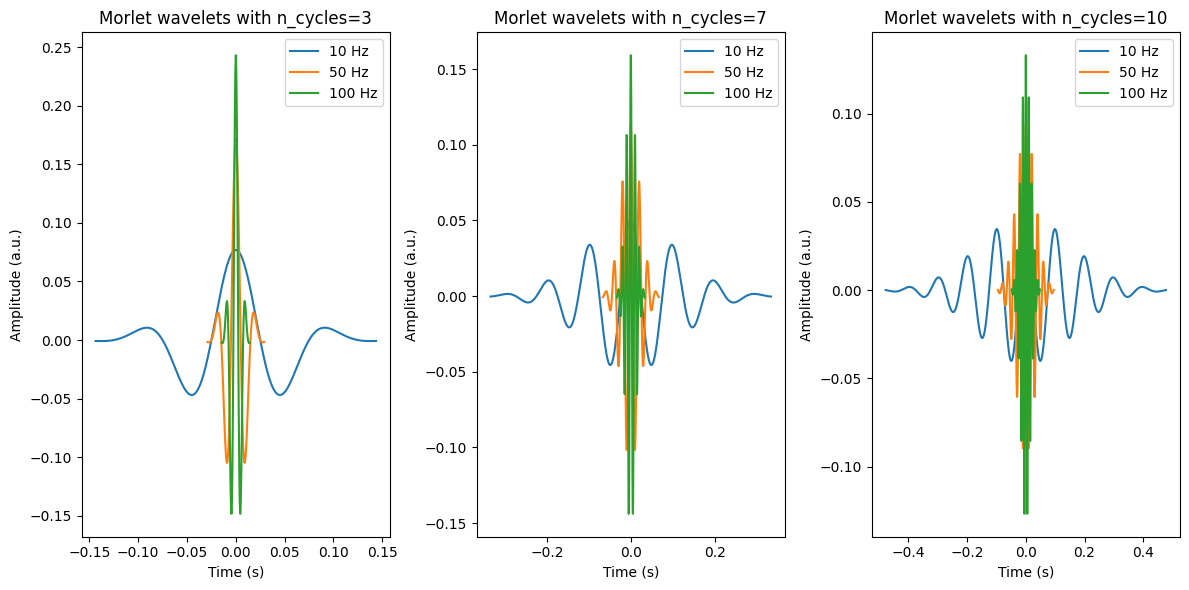

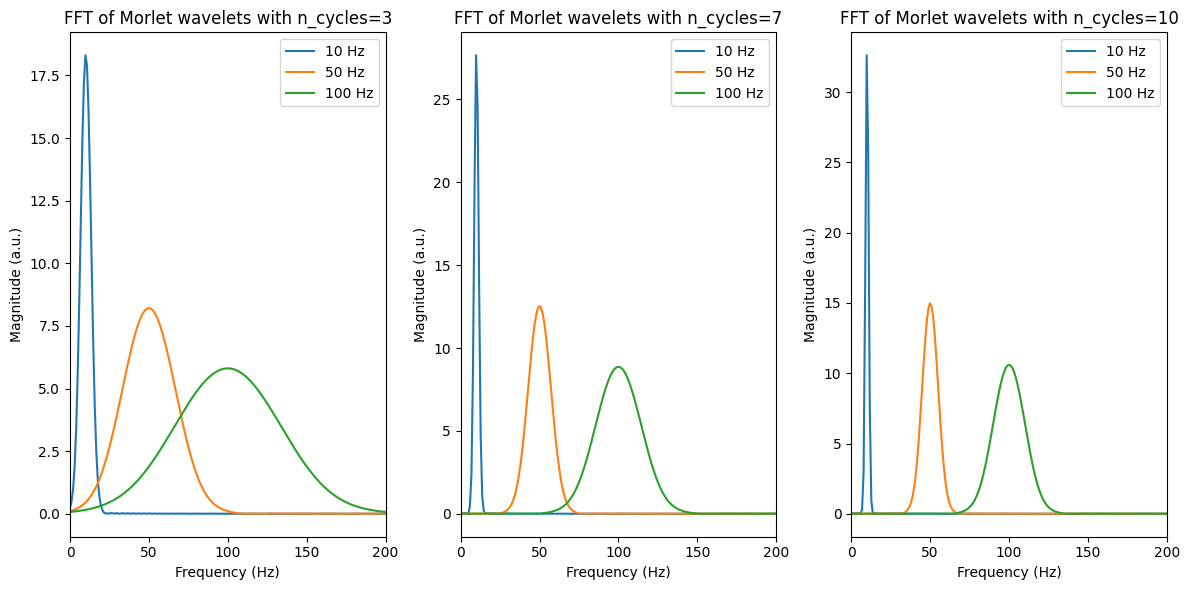

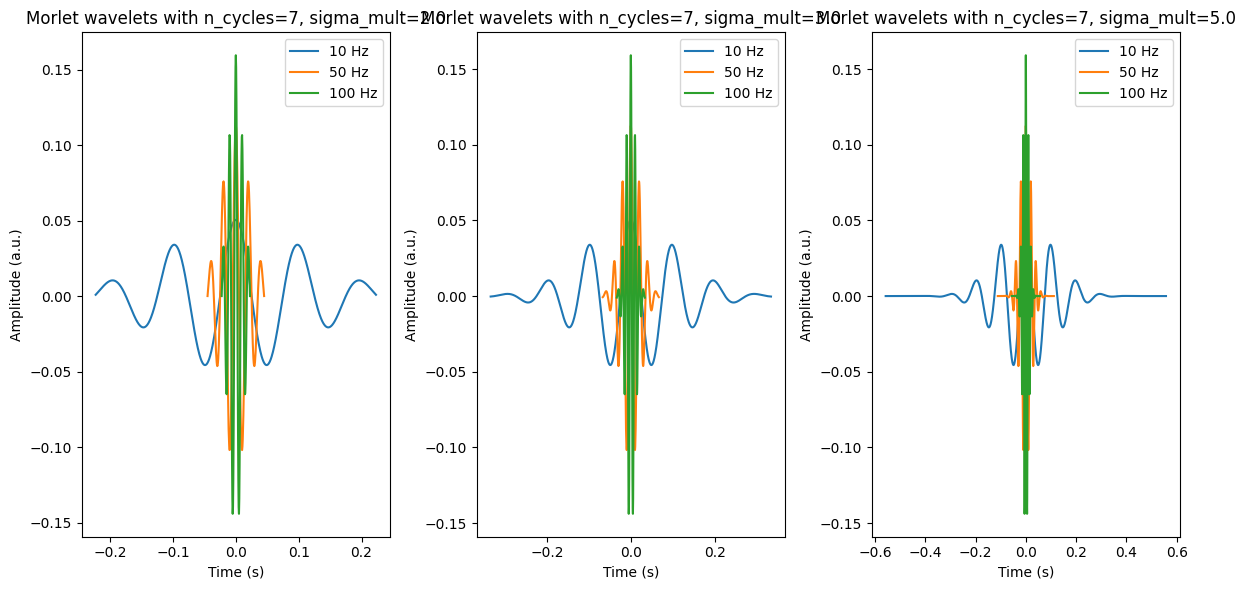

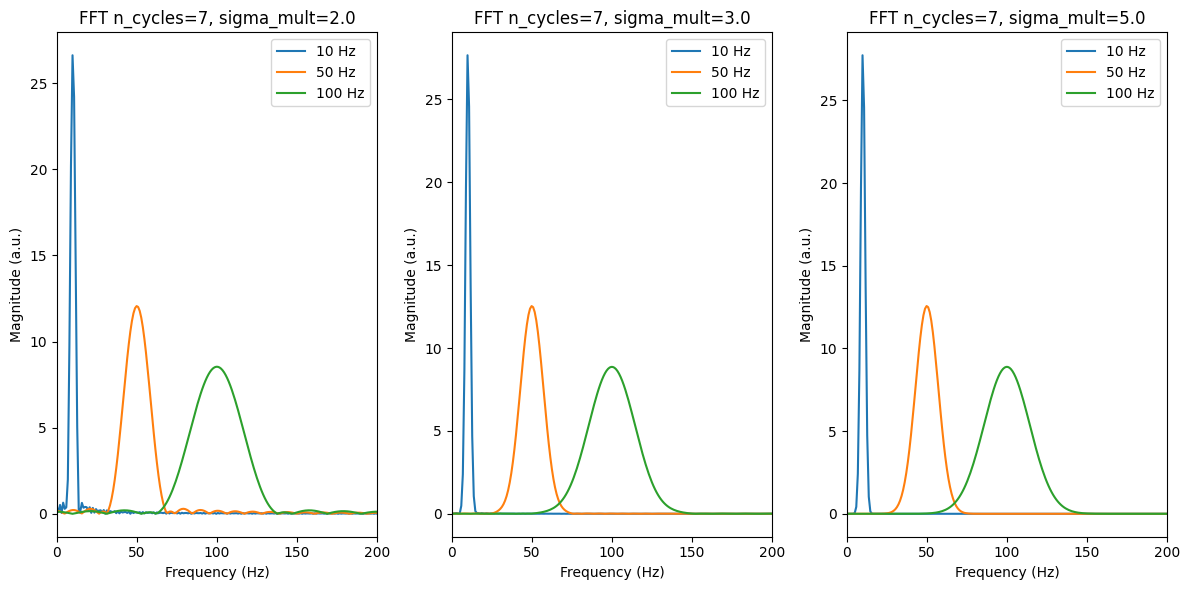

In [102]:
# plot wavelet time support for a few example frequencies and n_cycles settings
fs = 2000
freqs_to_plot = [10, 50, 100]
n_cycles_settings = [3, 7, 10]

plt.figure(figsize=(12, 6))
for i, n_cycles in enumerate(n_cycles_settings):
    plt.subplot(1, len(n_cycles_settings), i+1)
    for f in freqs_to_plot:
        tw, w = morlet_wavelet(f, fs, n_cycles, sigma_mult=3.0, normalize="unit_energy")
        plt.plot(tw, np.real(w), label=f"{f} Hz")
    plt.title(f"Morlet wavelets with n_cycles={n_cycles}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (a.u.)")
    #plt.xlim(-0.5, 0.5)
    plt.legend()
plt.tight_layout()
plt.show()

# plot frequency-domain representation of the wavelets to confirm normalization and frequency specificity
plt.figure(figsize=(12, 6))

n_fft = 2048

for i, n_cycles in enumerate(n_cycles_settings):
    plt.subplot(1, len(n_cycles_settings), i+1)

    for f in freqs_to_plot:
        tw, w = morlet_wavelet(f, fs, n_cycles, sigma_mult=3.0, normalize="unit_energy")

        w_fft = np.fft.fft(w, n=n_fft)
        freqs_fft = np.fft.fftfreq(n_fft, d=1/fs)

        pos = freqs_fft >= 0
        plt.plot(freqs_fft[pos], np.abs(w_fft[pos]), label=f"{f} Hz")

    plt.title(f"FFT of Morlet wavelets with n_cycles={n_cycles}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (a.u.)")
    plt.xlim(0, 200)
    plt.legend()

plt.tight_layout()
plt.show()


# try n_cycles 7 but different sigma_mult to see how it affects the time support and frequency specificity of the wavelet
plt.figure(figsize=(12, 6))
n_cycles = 7
sigma_mult_settings = [2.0, 3.0, 5.0]
for i, sigma_mult in enumerate(sigma_mult_settings):
    plt.subplot(1, len(sigma_mult_settings), i+1)
    for f in freqs_to_plot:
        tw, w = morlet_wavelet(f, fs, n_cycles, sigma_mult=sigma_mult, normalize="unit_energy")
        plt.plot(tw, np.real(w), label=f"{f} Hz")
    plt.title(f"Morlet wavelets with n_cycles={n_cycles}, sigma_mult={sigma_mult}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (a.u.)")
    #plt.xlim(-0.5, 0.5)
    plt.legend()
plt.tight_layout()
plt.show()

# plot FFT of these wavelets to see how sigma_mult affects the frequency specificity and side lobes
plt.figure(figsize=(12, 6))
n_fft = 2048
n_cycles = 7
for i, sigma_mult in enumerate(sigma_mult_settings):
    plt.subplot(1, len(sigma_mult_settings), i+1)
    for f in freqs_to_plot:
        tw, w = morlet_wavelet(f, fs, n_cycles, sigma_mult=sigma_mult, normalize="unit_energy")
        w_fft = np.fft.fft(w, n=n_fft)
        freqs_fft = np.fft.fftfreq(n_fft, d=1/fs)
        pos = freqs_fft >= 0
        plt.plot(freqs_fft[pos], np.abs(w_fft[pos]), label=f"{f} Hz")
    plt.title(f"FFT n_cycles={n_cycles}, sigma_mult={sigma_mult}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (a.u.)")
    plt.xlim(0, 200)
    plt.legend()
plt.tight_layout()
plt.show()

## Parameter sweep: compare decomposition settings

This section runs a few wavelet parameter sets to help you see how choices affect:
- time vs frequency smearing
- ITPC sharpness
- evoked vs induced separation
- edge effects (padding + wavelet length)

Edit `param_sets` to explore your own settings.


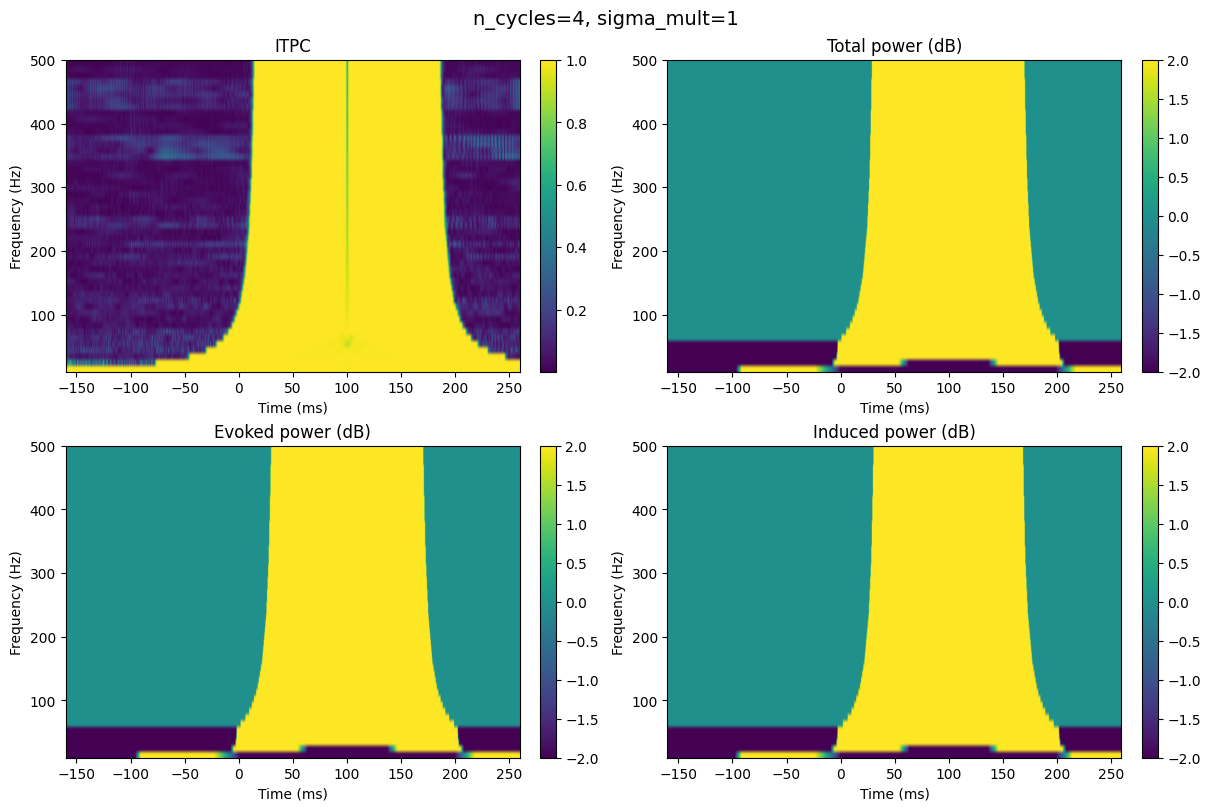

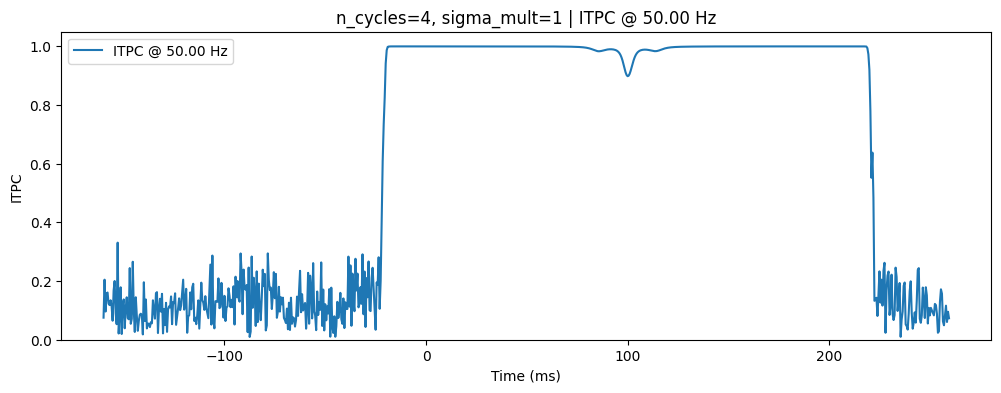

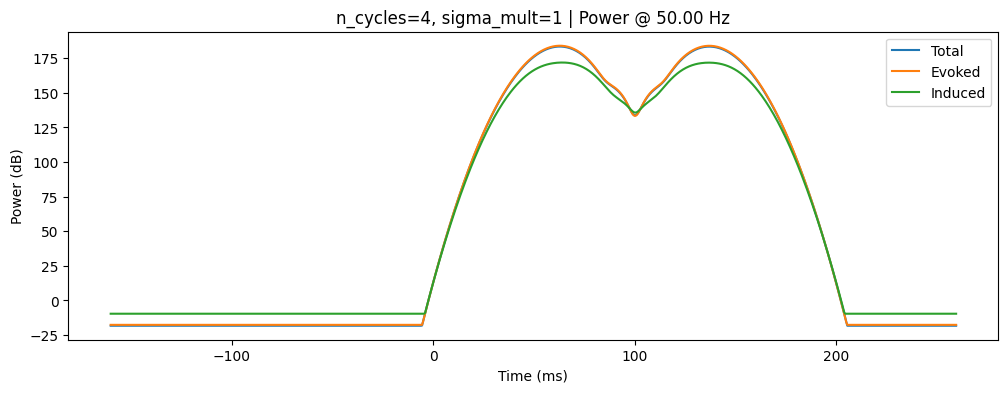

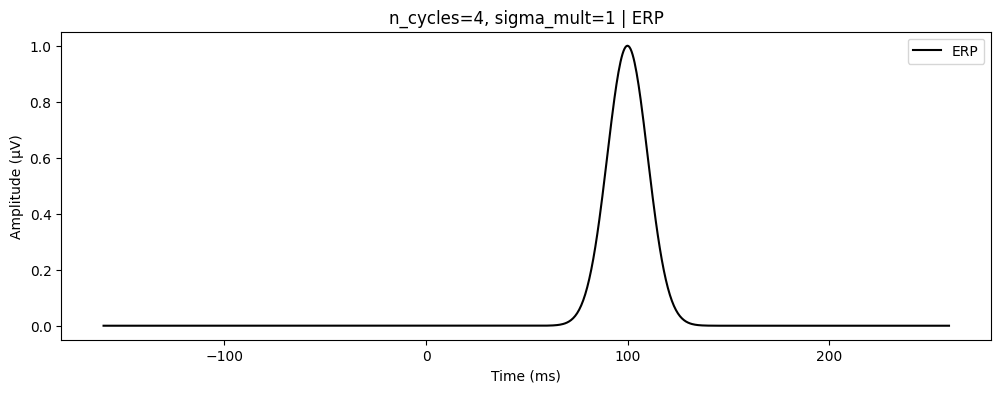

In [108]:
# generate a dataset with a single peak and low noise to make it easy to see the effects of the wavelet parameters
single_peak = [Peak("P50", latency_ms=100.0, amp_uv=1.0, width_ms=10.0)]
dataset = Dataset(peaks=single_peak, fs=2000, noise_rms_uv=0.0, pad_frac=2)
dataset.generate_trials(n_trials=300)

# define a few parameter sets to compare
param_sets = [
    {"n_cycles": 4, "sigma_mult": 3.0, "title": "n_cycles=4, sigma_mult=1"}
]

freqs_hz = np.linspace(10, 500, 50)
# run the parameter sets and plot results
for params in param_sets:
    metrics = compute_itpc_and_power(
        trials=np.array([sig for _, sig in dataset.trials]),
        fs=dataset.fs,
        freqs_hz=freqs_hz,
        n_cycles=params["n_cycles"],
        sigma_mult=params["sigma_mult"],
        pad_mode="reflect",
        normalize="unit_energy",
    )
    plot_tf_panels(
        t_ms=dataset.trials[0][0], # all trials have same time vector
        freqs_hz=freqs_hz,
        metrics=metrics,
        title=params["title"],
        baseline_ms=(-20, 0),
        vlim_db=(-2, 2),
    )
    plot_freq_traces(
        t_ms=dataset.trials[0][0],
        freqs_hz=freqs_hz,
        metrics=metrics,
        target_hz=50,
        title=params["title"],
        baseline_ms=(-20, 0),
    )

    #plot ERP for reference
    t_ms, avg_sig = dataset.average()
    plt.figure(figsize=(12, 4))
    plt.plot(t_ms, avg_sig, label="ERP", color="black")
    plt.title(params["title"] + " | ERP")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.legend()
    plt.show()



In [83]:
# python

Created 48 parameter combinations
{'n_trials': 30, 'n_cycles': 3, 'sigma_mult': 2.0, 'itpc_peak': 0.7820950586655787, 'total_power_peak': 8.219515711472743}
{'n_trials': 30, 'n_cycles': 3, 'sigma_mult': 3.0, 'itpc_peak': 0.8953830693530727, 'total_power_peak': 10.144156213193407}
{'n_trials': 30, 'n_cycles': 3, 'sigma_mult': 4.0, 'itpc_peak': 0.8862893761950945, 'total_power_peak': 11.414931235742792}
{'n_trials': 30, 'n_cycles': 3, 'sigma_mult': 6.0, 'itpc_peak': 0.9320595220457407, 'total_power_peak': 11.998605575961012}
{'n_trials': 30, 'n_cycles': 5, 'sigma_mult': 2.0, 'itpc_peak': 0.768637117630179, 'total_power_peak': 8.737484534249244}
{'n_trials': 30, 'n_cycles': 5, 'sigma_mult': 3.0, 'itpc_peak': 0.8539790451821878, 'total_power_peak': 10.729270422251538}
{'n_trials': 30, 'n_cycles': 5, 'sigma_mult': 4.0, 'itpc_peak': 0.8463634424585358, 'total_power_peak': 8.334304772069983}
{'n_trials': 30, 'n_cycles': 5, 'sigma_mult': 6.0, 'itpc_peak': 0.7255115652084431, 'total_power_peak'

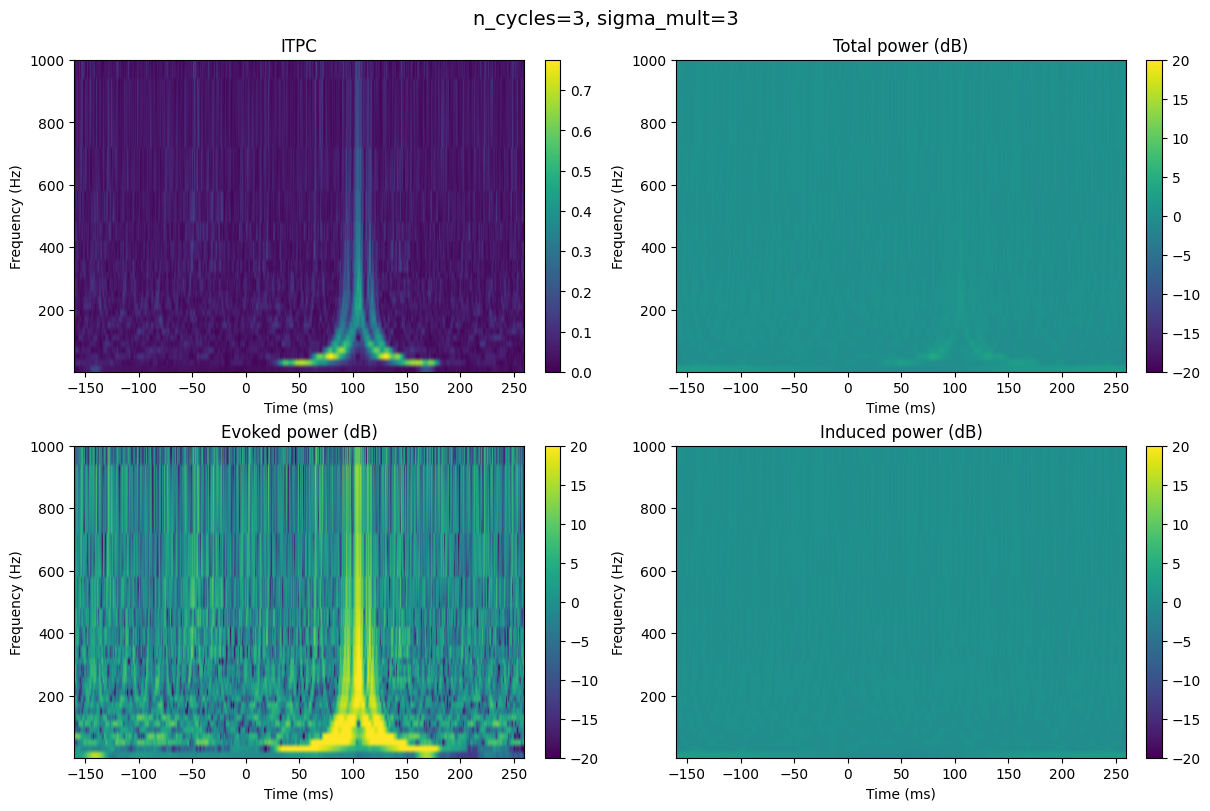

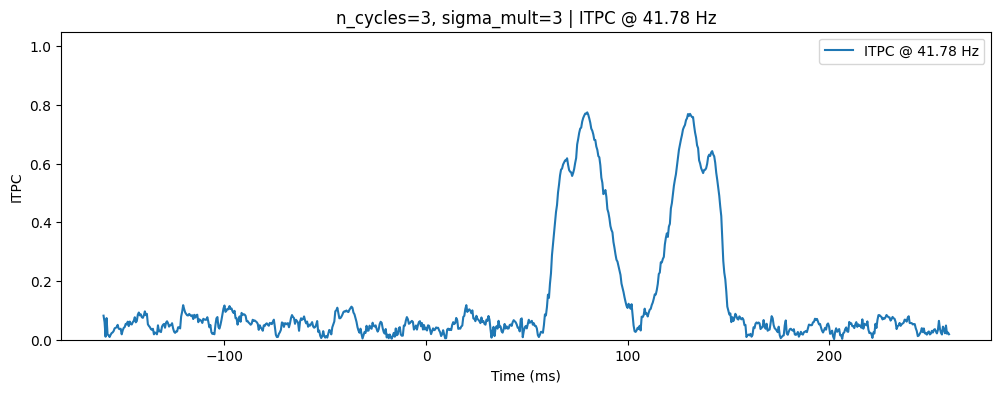

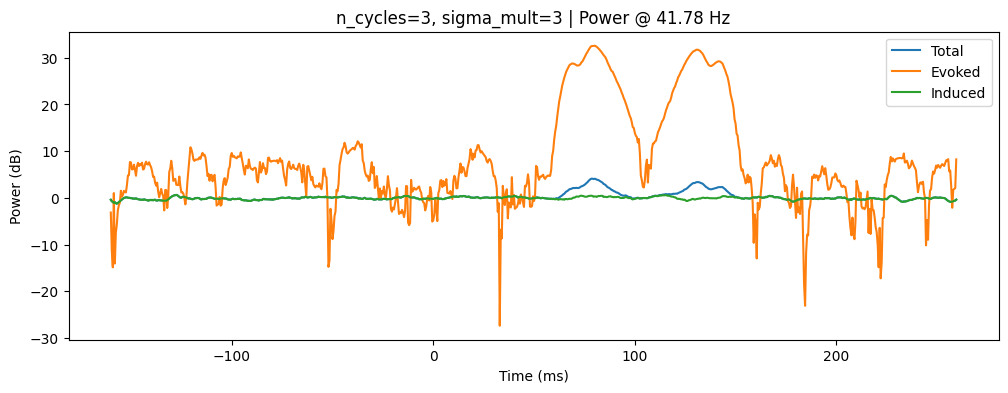

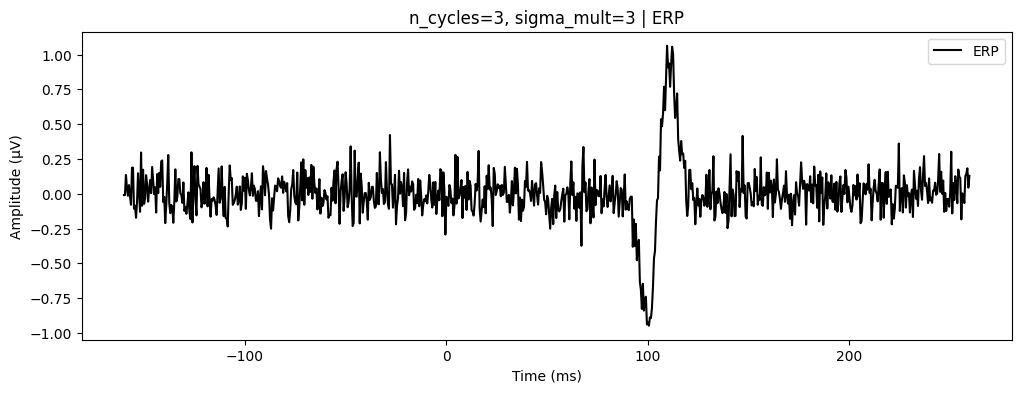

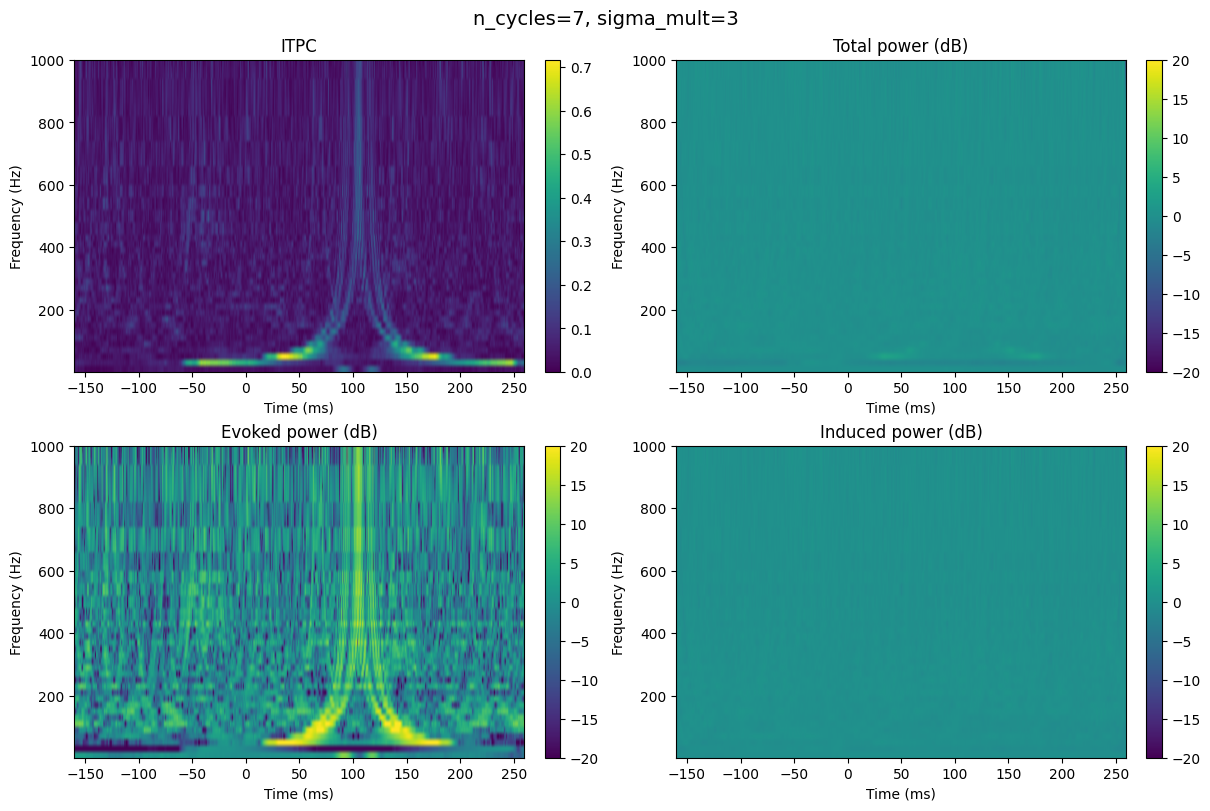

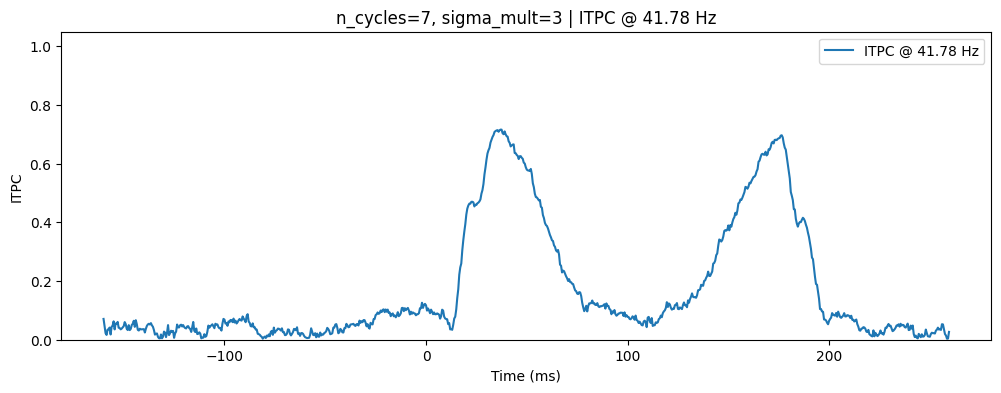

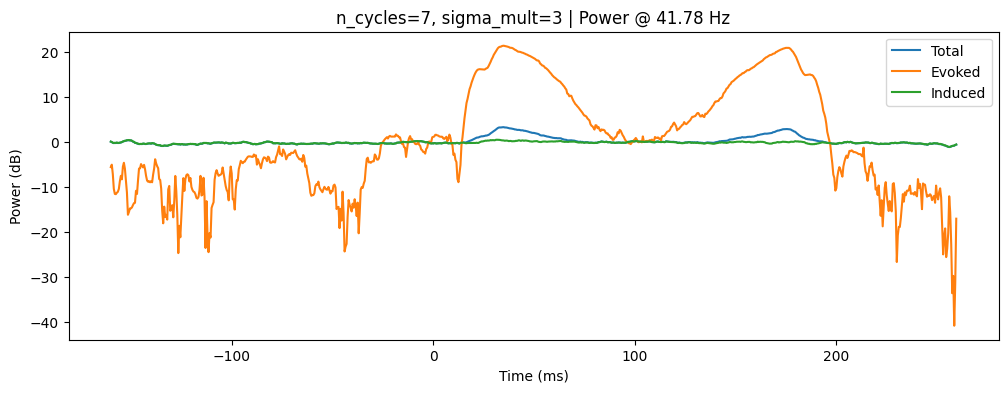

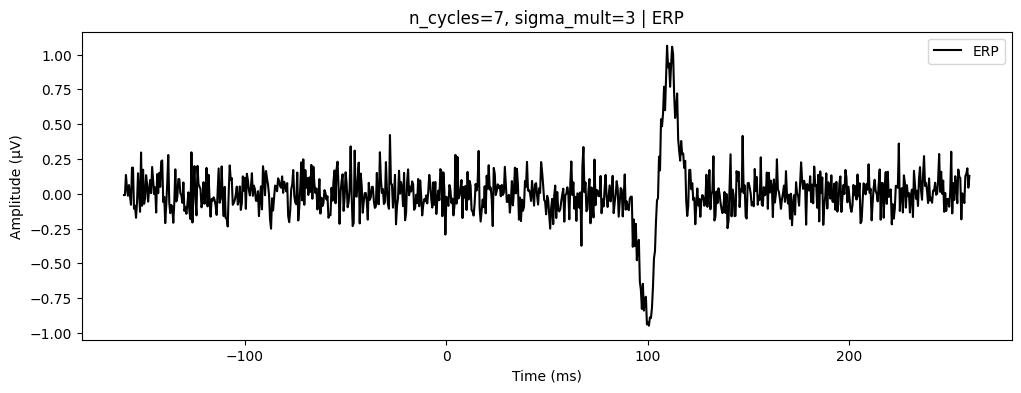

In [74]:
# lets try with a negative and positive peak to see how well the wavelet parameters can separate them in time and frequency
dual_peaks = [
    Peak("N1", latency_ms=100.0, amp_uv=-1.0, width_ms=4.0),
    Peak("P1", latency_ms=110.0, amp_uv=1.0, width_ms=4.0)
]
dataset = Dataset(peaks=dual_peaks, fs=2000, noise_rms_uv=2, rng_seed=42, pad_frac=2)
dataset.generate_trials(n_trials=300)

for params in param_sets:
    metrics = compute_itpc_and_power(
        trials=np.array([sig for _, sig in dataset.trials]),
        fs=dataset.fs,
        freqs_hz=freqs_hz,
        n_cycles=params["n_cycles"],
        sigma_mult=params["sigma_mult"],
        pad_mode="reflect",
        normalize="unit_energy",
    )
    plot_tf_panels(
        t_ms=dataset.trials[0][0], # all trials have same time vector
        freqs_hz=freqs_hz,
        metrics=metrics,
        title=params["title"],
        baseline_ms=(-20, 0),
        vlim_db=(-20, 20),
    )
    plot_freq_traces(
        t_ms=dataset.trials[0][0],
        freqs_hz=freqs_hz,
        metrics=metrics,
        target_hz=50,
        title=params["title"],
        baseline_ms=(-20, 0),
    )

    #plot ERP for reference
    t_ms, avg_sig = dataset.average()
    plt.figure(figsize=(12, 4))
    plt.plot(t_ms, avg_sig, label="ERP", color="black")
    plt.title(params["title"] + " | ERP")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.legend()
    plt.show()